# Python Intro Class

## Checking necessary packages
First we will check if we have all the necessary packages.

Run this first. 
If a package is missing, install it with `pip install numpy scipy matplotlib`.

In [7]:
import numpy
import scipy
import matplotlib.pyplot as plot

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
!pip install matplotlib

## Just variable declaration for understanding

In [1]:
print("Hello")

Hello


In [2]:
a = 1
b = 2 
x = a + b 
print(x)

3


In [3]:
z = x + 3

In [4]:
print(z)


6


## Starting from here | Main work

### Setup

In [9]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import stats
from scipy.io import loadmat

print(np.__version__)

Matplotlib is building the font cache; this may take a moment.


2.3.5


### Numpy exploration

In [12]:
# v = np.array([2, 4, 6, 8, 10])
v = np.array( [2, 4, 6, 8, 10] )

print(v)

[ 2  4  6  8 10]


In [14]:
print('First element of v: ', v[0])

First element of v:  2


In [15]:
print('Last element of v: ', v[-1])

Last element of v:  10


In [17]:
print('Three elements: ', v[1:4])

Three elements:  [4 6 8]


In [18]:
zeros = np.zeros(4)
print(zeros)


[0. 0. 0. 0.]


In [19]:
ones = np.ones(5)
print(ones)

[1. 1. 1. 1. 1.]


In [21]:
print(np.linspace(0, 1, 11))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [22]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print(M)

[[1 2 3]
 [4 5 6]]


In [23]:
print(M.shape)

(2, 3)


### EEG data 

In [24]:
d = loadmat('../data/anova_data.mat')
print('keys:', [k for k in d if not k.startswith('__')])

control = d['control'].ravel()    # saved as (1, 16) -> flatten to (16,)
mild    = d['mild'].ravel()
severe  = d['severe'].ravel()
print('control n =', control.size, '| first 3 values:', control[:3].round(2))

keys: ['control', 'mild', 'severe', 'values', 'group', 'measure']
control n = 16 | first 3 values: [8.19 2.31 7.15]


In [25]:
def describe(name, x):
    n = x.size
    print(f'{name:9s} n={n:2d}  mean={x.mean():6.2f}  '
          f'median={np.median(x):6.2f}  std={x.std(ddof=1):6.2f}  '
          f'SEM={x.std(ddof=1)/np.sqrt(n):6.2f}')

for nm, x in [('control', control), ('mild', mild), ('severe', severe)]:
    describe(nm, x)

control   n=16  mean=  6.31  median=  6.49  std=  1.39  SEM=  0.35
mild      n=16  mean=  5.11  median=  5.06  std=  1.38  SEM=  0.34
severe    n=16  mean=  2.96  median=  2.77  std=  0.85  SEM=  0.21


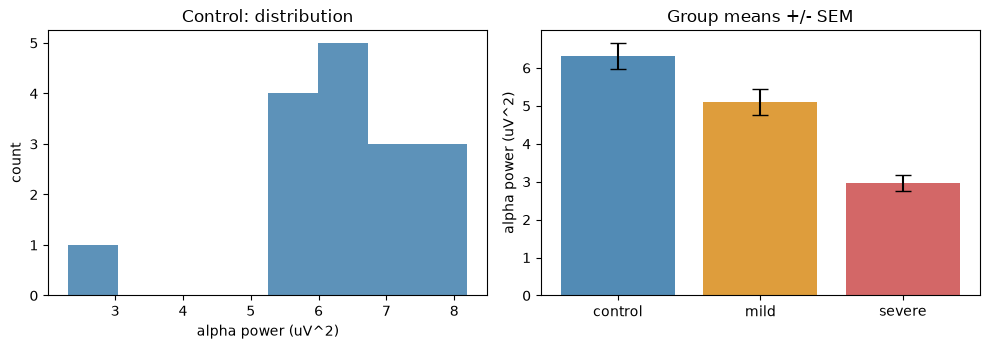

In [26]:
fig, ax = plot.subplots(1, 2, figsize=(10, 3.6))

# histogram of one group
ax[0].hist(control, bins=8, color='#3477a8', alpha=0.8)
ax[0].set(title='Control: distribution', xlabel='alpha power (uV^2)', ylabel='count')

# bar chart of the three group means +/- SEM
groups = [control, mild, severe]
names  = ['control', 'mild', 'severe']
means  = [g.mean() for g in groups]
sems   = [g.std(ddof=1)/np.sqrt(g.size) for g in groups]
ax[1].bar(names, means, yerr=sems, capsize=6,
          color=['#3477a8', '#d98c1a', '#cc4c4c'], alpha=0.85)
ax[1].set(title='Group means +/- SEM', ylabel='alpha power (uV^2)')
plot.tight_layout(); plot.show()

In [27]:
# two independent groups: control vs severe
t, p = stats.ttest_ind(control, severe)
print(f'ttest_ind control vs severe:  t = {t:.2f}, p = {p:.3e}')

# one-sample: is control different from 0?
t1, p1 = stats.ttest_1samp(control, 0)
print(f'ttest_1samp control vs 0:     t = {t1:.2f}, p = {p1:.3e}')

ttest_ind control vs severe:  t = 8.25, p = 3.301e-09
ttest_1samp control vs 0:     t = 18.17, p = 1.263e-11
